## Label Regions

### GLaMM

In [ ]:
import os
import re
import torch
import numpy as np

from transformers import AutoTokenizer, CLIPImageProcessor

from eval.utils import *  # brings in grounding_image_ecoder_preprocess
from model.GLaMM import GLaMMForCausalLM
from model.llava import conversation as conversation_lib
from model.llava.mm_utils import tokenizer_image_token
from model.SAM.utils.transforms import ResizeLongestSide
from tools.utils import (
    DEFAULT_IM_END_TOKEN,
    DEFAULT_IM_START_TOKEN,
    DEFAULT_IMAGE_TOKEN,
    IMAGE_TOKEN_INDEX,
)

# GLaMM-RegCap-VG tends to produce finer-grained part/attribute descriptions than
# GLaMM-RegCap-RefCOCOg (which is tuned more for distinguishing similar objects
# in a scene) -- swap the path below if you want to compare.
HF_MODEL_PATH = "MBZUAI/GLaMM-RegCap-VG"
CONV_TYPE = "llava_v1"
IMAGE_SIZE = 1024
MODEL_MAX_LENGTH = 512
USE_MM_START_END = True

tokenizer_glamm = AutoTokenizer.from_pretrained(
    HF_MODEL_PATH,
    cache_dir=None,
    model_max_length=MODEL_MAX_LENGTH,
    padding_side="right",
    use_fast=False,
)
tokenizer_glamm.pad_token = tokenizer_glamm.unk_token
seg_token_idx = tokenizer_glamm("[SEG]", add_special_tokens=False).input_ids[0]

torch_dtype = torch.bfloat16  # matches GLaMM's default inference precision

model_glamm = GLaMMForCausalLM.from_pretrained(
    HF_MODEL_PATH,
    low_cpu_mem_usage=True,
    seg_token_idx=seg_token_idx,
    torch_dtype=torch_dtype,
)
model_glamm.config.eos_token_id = tokenizer_glamm.eos_token_id
model_glamm.config.bos_token_id = tokenizer_glamm.bos_token_id
model_glamm.config.pad_token_id = tokenizer_glamm.pad_token_id

model_glamm.get_model().initialize_vision_modules(model_glamm.get_model().config)
vision_tower = model_glamm.get_model().get_vision_tower()
vision_tower.to(dtype=torch_dtype)

model_glamm = model_glamm.bfloat16().cuda()
vision_tower = model_glamm.get_model().get_vision_tower()
vision_tower.to(device="cuda")

clip_image_processor = CLIPImageProcessor.from_pretrained(model_glamm.config.vision_tower)
grounding_transform = ResizeLongestSide(IMAGE_SIZE)

model_glamm.eval()
print("GLaMM loaded.")

/home/yishin/miniconda3/envs/patent/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'eval'

### InterVL

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

In [ ]:
model_internvl = AutoModel.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="cuda",
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True
).eval()

Loading checkpoint shards: 100%|██████████| 4/4 [00:06<00:00,  1.67s/it]


In [ ]:
def make_highlighted_full_image_from_mask(image_rgb, mask, alpha=120):
    """
    Highlights the actual SAM mask shape on the full image.
    Returns a PIL Image with yellow fill and red contour outline.
    """
    img = Image.fromarray(image_rgb).convert("RGBA")

    # Yellow fill over the mask area
    overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.uint8)
    overlay[mask > 0] = [255, 255, 0, alpha]
    overlay_img = Image.fromarray(overlay, mode="RGBA")
    highlighted = Image.alpha_composite(img, overlay_img)

    # Red contour outline around the mask boundary
    highlighted_cv = cv2.cvtColor(np.array(highlighted.convert("RGB")), cv2.COLOR_RGB2BGR)
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(highlighted_cv, contours, -1, (0, 0, 255), 3)

    return Image.fromarray(cv2.cvtColor(highlighted_cv, cv2.COLOR_BGR2RGB))

In [ ]:
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),
    T.Resize((448, 448), interpolation=InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [ ]:
def describe_sam_cells_with_internvl(
    image_rgb,
    grid_cells,
    title,
    model_internvl,
    tokenizer_internvl,
    device="cuda",
    padding_pct=0.3
):
    model_dtype = next(model_internvl.parameters()).dtype
    results = []

    for cell in grid_cells:
        # Use mask-based highlight if mask exists, else fall back to bbox
        if "mask" in cell:
            highlighted_full = make_highlighted_full_image_from_mask(
                image_rgb, cell["mask"]
            )
        else:
            highlighted_full = Image.fromarray(image_rgb).convert("RGB")

        # Crop with padding around bbox for surrounding context
        x1, y1, x2, y2 = cell["bbox"]
        pad_x = int((x2 - x1) * padding_pct)
        pad_y = int((y2 - y1) * padding_pct)
        img_w, img_h = highlighted_full.size
        crop_x1 = max(0, x1 - pad_x)
        crop_y1 = max(0, y1 - pad_y)
        crop_x2 = min(img_w, x2 + pad_x)
        crop_y2 = min(img_h, y2 + pad_y)
        cropped = highlighted_full.crop((crop_x1, crop_y1, crop_x2, crop_y2))

        pixel_values = transform(cropped).unsqueeze(0).to(device, dtype=model_dtype)

        prompt = (
            f"<image>\n"
            f"This is a patent design drawing of a {title}. "
            f"The yellow highlighted region marks a specific part.\n"
            f"In one sentence, identify what part of the {title} "
            f"the yellow highlighted region represents. "
            f"Pay close attention to openings, holes, cavities, or recesses. "
            f"Be specific to the part, not the shape."
        )

        with torch.no_grad():
            response = model_internvl.chat(
                tokenizer=tokenizer_internvl,
                pixel_values=pixel_values,
                question=prompt,
                generation_config=dict(
                    max_new_tokens=50,
                    do_sample=False
                )
            )

        description = response.strip()

        results.append({
            "cell_id": cell["id"],
            "bbox":    cell["bbox"],
            "description": description
        })

        print(f"  Cell {cell['id']} | {description}")

    return results

In [ ]:
def overlay_keywords_on_grid(image_rgb, results, font_size=30):
    img = Image.fromarray(image_rgb).convert("RGB")
    output = img.copy()
    draw = ImageDraw.Draw(output, "RGBA")

    font_paths = [
        "/home/yishin/keith/patent_research/fonts/arial.ttf"
    ]

    font = None
    for path in font_paths:
        try:
            font = ImageFont.truetype(path, font_size)
            break
        except:
            pass

    if font is None:
        font = ImageFont.load_default()

    for r in results:
        x1, y1, x2, y2 = r["bbox"]

        # Wrap long sentences to fit within the grid cell width
        cell_width = x2 - x1
        words = r["description"].split()
        lines, current_line = [], []
        for word in words:
            test_line = " ".join(current_line + [word])
            test_bbox = draw.textbbox((0, 0), test_line, font=font)
            if test_bbox[2] - test_bbox[0] <= cell_width - 20:
                current_line.append(word)
            else:
                if current_line:
                    lines.append(" ".join(current_line))
                current_line = [word]
        if current_line:
            lines.append(" ".join(current_line))

        label = "\n".join(lines)

        text_bbox = draw.multiline_textbbox((x1, y1), label, font=font)
        text_w = text_bbox[2] - text_bbox[0]
        text_h = text_bbox[3] - text_bbox[1]

        draw.rectangle((x1, y1, x2, y2), outline=(255, 0, 0, 255), width=6)

        draw.rectangle(
            (x1, y1, x1 + text_w + 20, y1 + text_h + 20),
            fill=(255, 255, 0, 220)
        )

        draw.multiline_text(
            (x1 + 10, y1 + 10),
            label,
            fill=(0, 0, 0, 255),
            font=font,
            spacing=6
        )

    return output

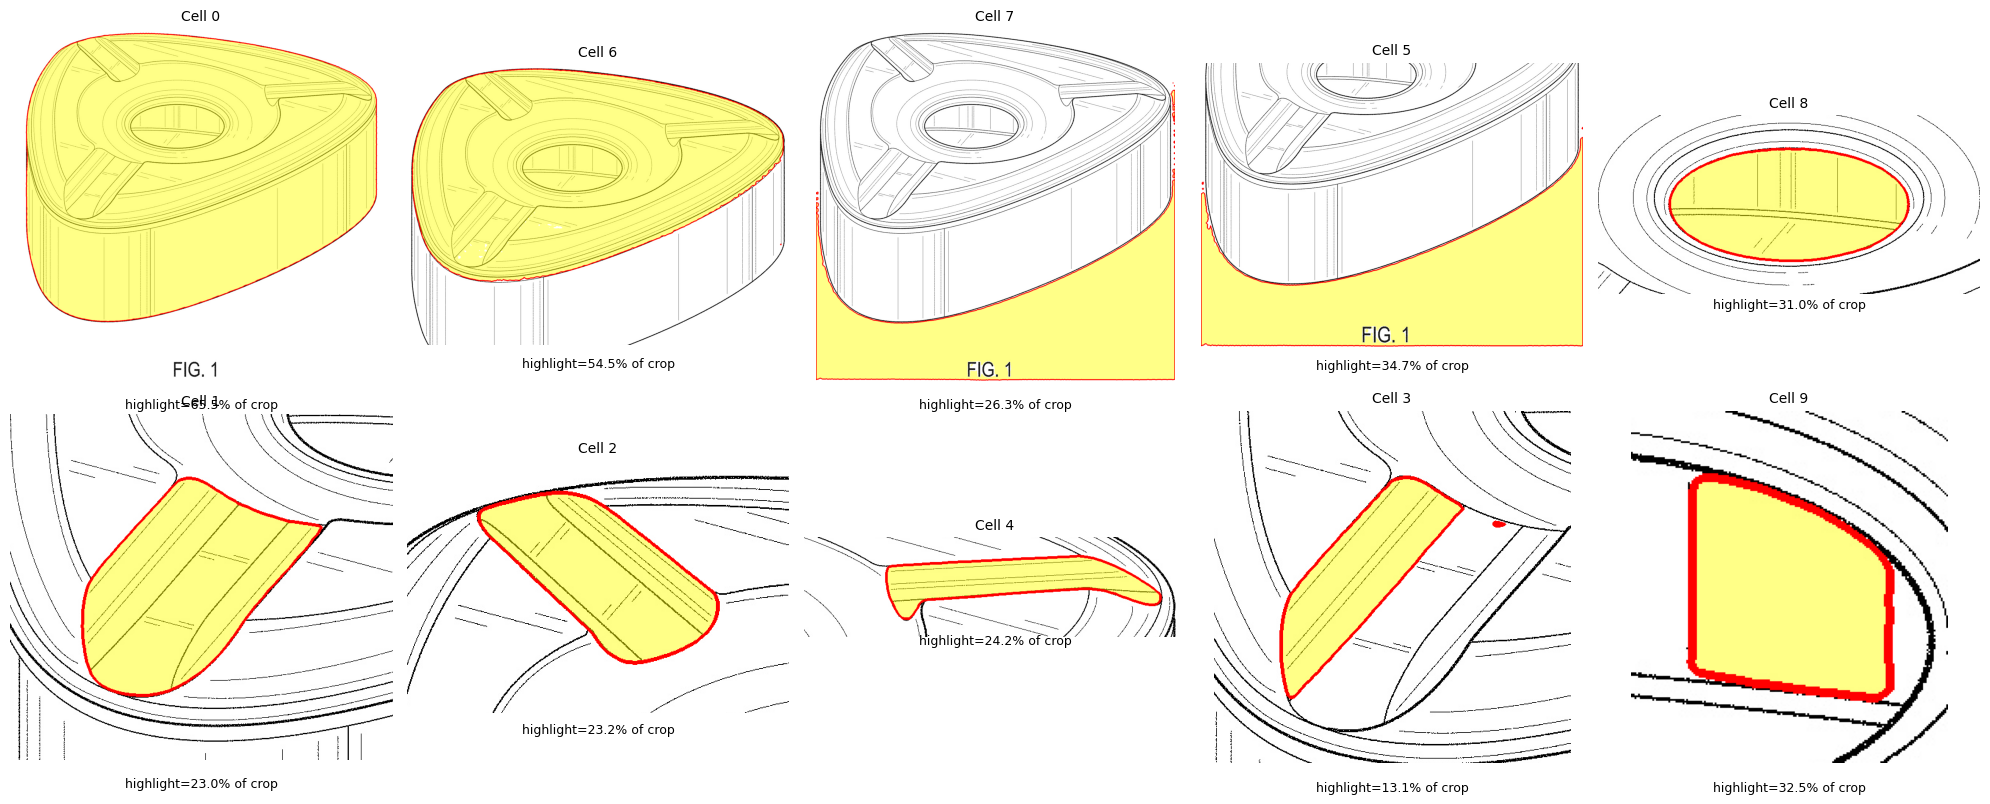

Saved to /home/yishin/keith/patent_research/debug/model_inputs.png


In [ ]:
def debug_visualize_model_inputs(image_rgb, grid_cells, padding_pct=0.3, save_path="/home/yishin/keith/patent_research/debug/model_inputs.png"):
    """
    Renders exactly what InternVL2 sees per cell: highlighted-full-image -> cropped.
    Use this to verify the yellow/red highlight actually lands inside each crop
    and looks visually distinct across cells.
    """
    n = len(grid_cells)
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    for idx, cell in enumerate(grid_cells):
        if "mask" in cell:
            highlighted_full = make_highlighted_full_image_from_mask(image_rgb, cell["mask"])
        else:
            highlighted_full = Image.fromarray(image_rgb).convert("RGB")

        x1, y1, x2, y2 = cell["bbox"]
        pad_x = int((x2 - x1) * padding_pct)
        pad_y = int((y2 - y1) * padding_pct)
        img_w, img_h = highlighted_full.size
        crop_x1 = max(0, x1 - pad_x)
        crop_y1 = max(0, y1 - pad_y)
        crop_x2 = min(img_w, x2 + pad_x)
        crop_y2 = min(img_h, y2 + pad_y)
        cropped = highlighted_full.crop((crop_x1, crop_y1, crop_x2, crop_y2))

        axes[idx].imshow(cropped)
        axes[idx].set_title(f"Cell {cell['id']}", fontsize=10)
        axes[idx].axis("off")

        # quick numeric check: what fraction of the crop is actually highlighted?
        if "mask" in cell:
            crop_mask = cell["mask"][crop_y1:crop_y2, crop_x1:crop_x2]
            frac = crop_mask.sum() / crop_mask.size
            axes[idx].text(0.5, -0.08, f"highlight={frac:.1%} of crop",
                            transform=axes[idx].transAxes, ha="center", fontsize=9)

    for j in range(idx+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"Saved to {save_path}")

debug_visualize_model_inputs(image_rgb, grid_cells)

  Cell 0 | The yellow highlighted region represents the ashtray's main cavity where cigarette ashes and butts are collected.
  Cell 6 | The yellow highlighted region represents the central cavity of the ashtray where cigarette butts and ash would be collected.
  Cell 7 | The yellow highlighted region represents the ashtray's main cavity where cigarette ashes and butts are collected.
  Cell 5 | The yellow highlighted region represents the recessed area where cigarette butts are placed for disposal.
  Cell 8 | The yellow highlighted region represents the interior cavity of the Ashtray where cigarette butts or ash would be placed.
  Cell 1 | The yellow highlighted region represents the ashtray's main cavity where cigarette ashes and butts are collected.
  Cell 2 | The yellow highlighted region represents the interior cavity of the Ashtray where cigarette butts or ash would be placed.
  Cell 4 | The yellow highlighted region represents the ashtray's main cavity where cigarette ashes and bu

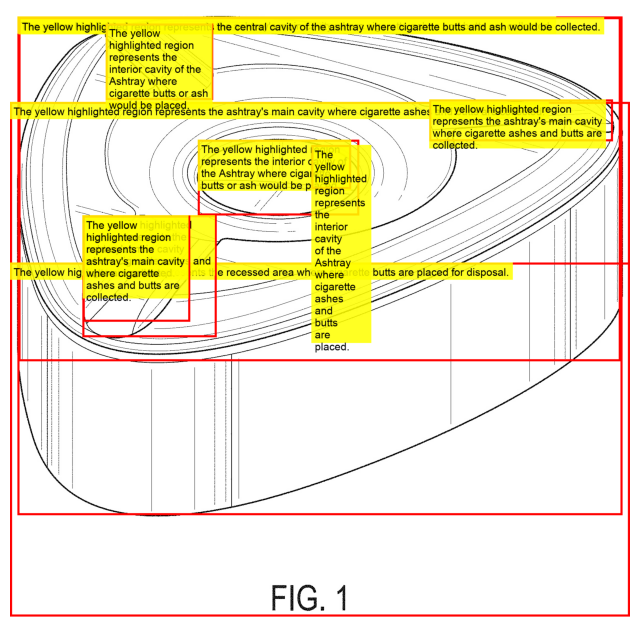

In [ ]:
results = describe_sam_cells_with_internvl(
    image_rgb=image_rgb,
    grid_cells=grid_cells,
    title=title,
    model_internvl=model_internvl,
    tokenizer_internvl=tokenizer,
)

# Step 3: Visualise the descriptions on the image
output = overlay_keywords_on_grid(image_rgb, results, font_size=30)

plt.figure(figsize=(8, 8))
plt.imshow(output)
plt.axis("off")
plt.show()